# EDA

c:\Users\SSAFY\Downloads\2026-ssafy-ai-15-2\Ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
이미지 파일 분석 중: 100%|██████████| 5073/5073 [00:07<00:00, 683.02it/s]
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_12712\1612303374.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='answer', order=['a', 'b', 'c', 'd'], ax=axes[0, 0], palette='viridis')


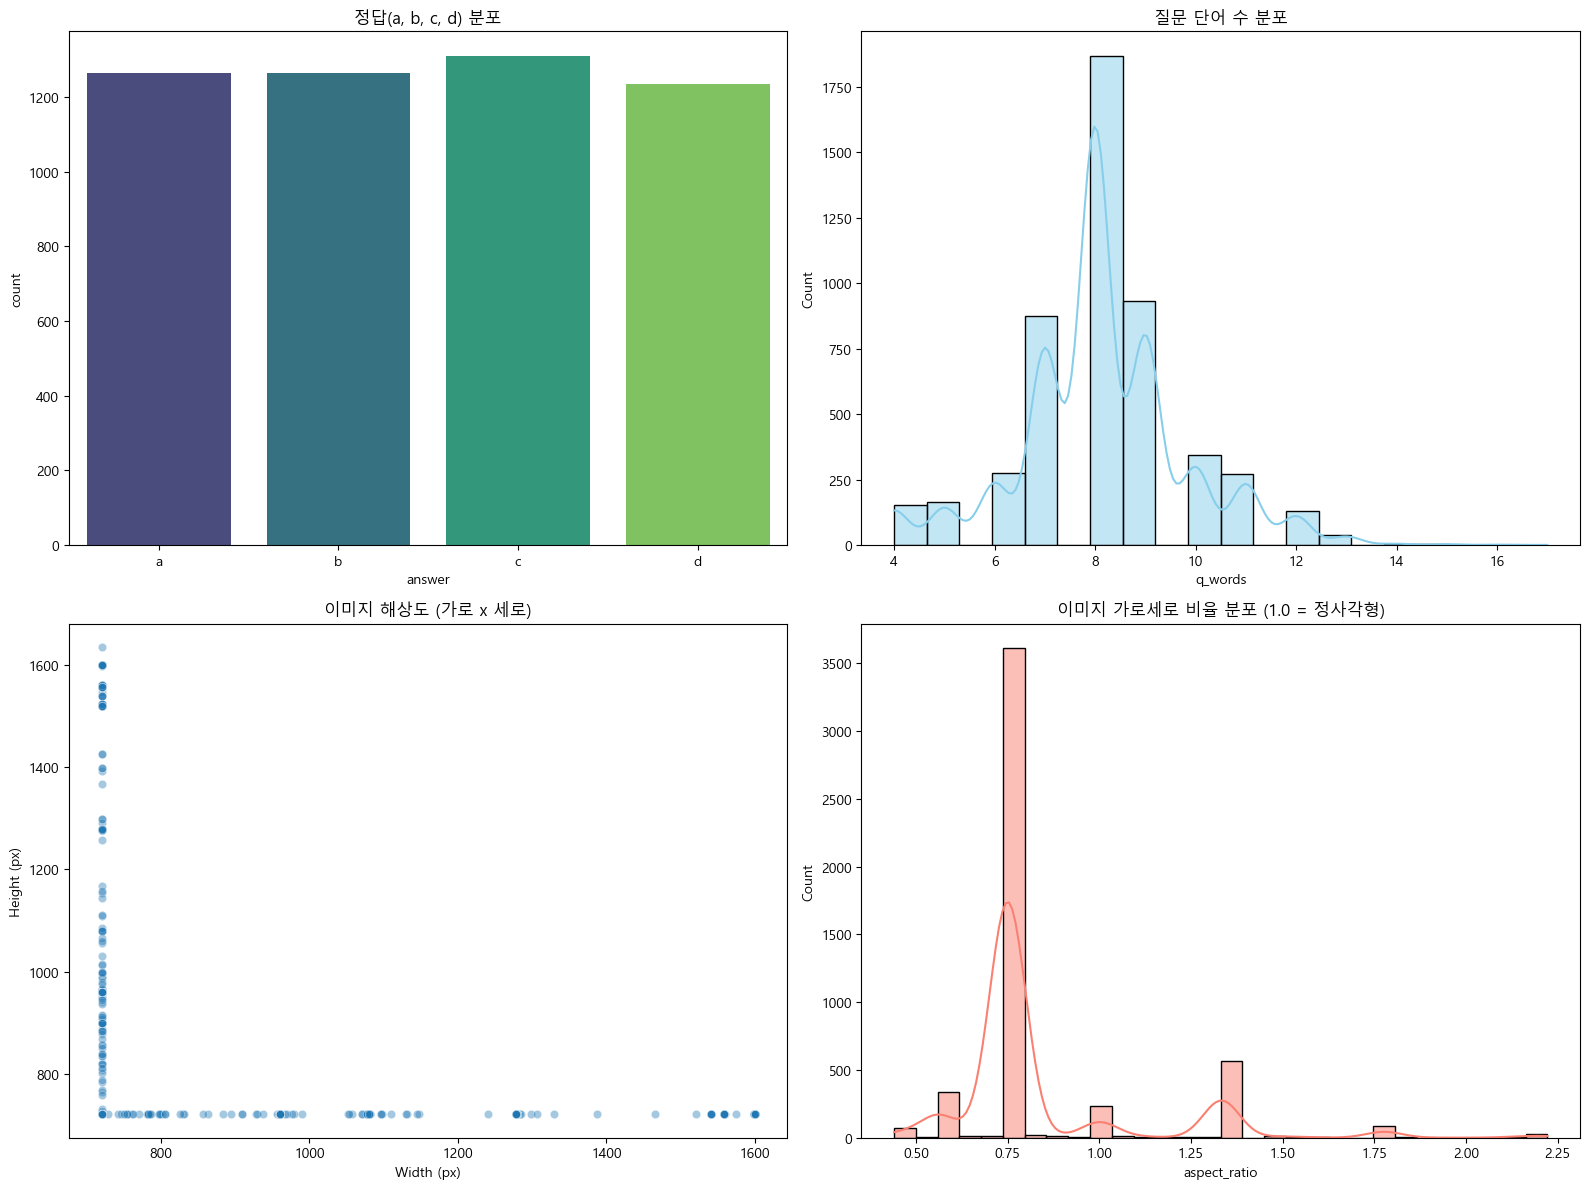


[ EDA 요약 통계 ]
           q_words        width       height  aspect_ratio
count  5073.000000  5073.000000  5073.000000   5073.000000
mean      8.136803   765.918786   943.668047      0.845769
std       1.676467   127.698283   153.136997      0.272294
min       4.000000   720.000000   720.000000      0.440098
25%       7.000000   720.000000   960.000000      0.750000
50%       8.000000   720.000000   960.000000      0.750000
75%       9.000000   720.000000   960.000000      0.750000
max      17.000000  1600.000000  1636.000000      2.222222


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

# 1. 데이터 로드 및 경로 설정
df = pd.read_csv('train.csv')
IMAGE_DIR = './train'  # 실제 이미지들이 들어있는 폴더 경로로 수정하세요.

# 2. 텍스트 데이터 분석 (질문 및 선지 길이)
df['q_len'] = df['question'].str.len()
df['q_words'] = df['question'].apply(lambda x: len(x.split()))

# 3. 이미지 메타데이터 분석 (해상도 및 비율)
image_stats = []
for path in tqdm(df['path'], desc="이미지 파일 분석 중"):
    # CSV의 path가 'train/train_0001.jpg' 형태라면 IMAGE_DIR과 적절히 합쳐야 합니다.
    # 만약 IMAGE_DIR 내부에 train 폴더가 또 있다면 경로를 조정하세요.
    full_path = os.path.join('.', path) 
    
    if os.path.exists(full_path):
        with Image.open(full_path) as img:
            w, h = img.size
            image_stats.append({'width': w, 'height': h, 'aspect_ratio': w/h})
    else:
        image_stats.append({'width': np.nan, 'height': np.nan, 'aspect_ratio': np.nan})

img_df = pd.DataFrame(image_stats)
df = pd.concat([df, img_df], axis=1)

# --- 시각화 ---
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) 정답 분포: 클래스 불균형 확인
sns.countplot(data=df, x='answer', order=['a', 'b', 'c', 'd'], ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('정답(a, b, c, d) 분포')

# (2) 질문 길이 분포: 프롬프트 max_length 결정용
sns.histplot(df['q_words'], bins=20, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('질문 단어 수 분포')

# (3) 이미지 해상도 분포: 모델 입력 사이즈(Resolution) 결정용
sns.scatterplot(data=df, x='width', y='height', alpha=0.4, ax=axes[1, 0])
axes[1, 0].set_title('이미지 해상도 (가로 x 세로)')
axes[1, 0].set_xlabel('Width (px)')
axes[1, 0].set_ylabel('Height (px)')

# (4) 가로세로 비율 분포: Resize 시 비율 유지 여부 결정용
sns.histplot(df['aspect_ratio'].dropna(), bins=30, kde=True, ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('이미지 가로세로 비율 분포 (1.0 = 정사각형)')

plt.tight_layout()
plt.show()

# 요약 통계량 출력
print("\n[ EDA 요약 통계 ]")
print(df[['q_words', 'width', 'height', 'aspect_ratio']].describe())

# 데이터 처리

In [6]:
import re
import os
from PIL import Image

def clean_vqa_question(text):
    """질문에서 불필요한 상투어구와 조사를 제거하여 핵심 키워드만 남김"""
    if not isinstance(text, str): return ""
    
    # 시작 문구 제거
    text = re.sub(r'사진\s*(속|에서|에\s*보이는|의)\s*', '', text)
    # 종결어미 및 조사 제거
    text = re.sub(r'(은|는|이|가)?\s*(무엇인가요|있나요|어느\s*것인가요|인가요|인가요\??)\s*\??', '', text)
    # 특수문자 제거 및 공백 정리
    text = re.sub(r'[^\w\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def get_optimized_image(image_path, target_size=(448, 448)): # Pro에서 돌릴 땐 다르게 변형
    """이미지를 모델 최적 해상도로 리사이징 (VRAM 절약 및 속도 향상)"""
    try:
        with Image.open(image_path) as img:
            if img.mode != "RGB":
                img = img.convert("RGB")
            # 비율 유지 없이 리사이징하거나, 필요시 Padding 처리를 추가할 수 있습니다.
            return img.resize(target_size, Image.Resampling.LANCZOS)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def build_refined_prompt(question, a, b, c, d):
    """영문 지시어가 포함된 최종 프롬프트 생성"""
    cleaned_q = clean_vqa_question(question)
    prompt = (
        f"Context: Analyze the image to answer the question.\n"
        f"Question: {cleaned_q}\n"
        f"Options: (a) {a} (b) {b} (c) {c} (d) {d}\n"
        f"Instruction: Select the correct option (a, b, c, or d).\n"
        f"Answer: ("
    )
    return prompt

In [ ]:
```
import os, re, math, random, gc
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import Dict, List, Any
from torchvision import transforms
from transformers import (
    AutoModelForVision2Seq,
    AutoProcessor,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from tqdm.auto import tqdm

######################################
# 1. 전역 설정
######################################
Image.MAX_IMAGE_PIXELS = None
device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
IMAGE_SIZE = 448
SEED = 42
random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

SYSTEM_INSTRUCT = (
    "You are a helpful visual question answering assistant. "
    "Answer using exactly one letter among a, b, c, or d. No explanation."
)

def build_mc_prompt(question, a, b, c, d):
    return (f"{question}\n(a) {a}\n(b) {b}\n(c) {c}\n(d) {d}\n\n"
            "정답을 반드시 a, b, c, d 중 하나의 소문자 한 글자로만 출력하세요.")

######################################
# 2. 데이터셋 및 콜레이터 정의
######################################
class VQAMCDataset(Dataset):
    def __init__(self, df, processor, train=True):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.train = train
        
        # 강력한 데이터 증강 설정
        if self.train:
            self.transform = transforms.Compose([
                # RandomHorizontalFlip: 50% 확률로 좌우 반전
                transforms.RandomHorizontalFlip(p=0.5),
                # ColorJitter: 밝기, 대비, 채도, 색상을 강하게 조절
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                # RandomRotation: 이미지를 최대 degrees도까지 무작위 회전
                transforms.RandomRotation(degrees=15, fill=255),
                # 색상에 의존하지 않고 질감을 보도록
                transforms.RandomGrayscale(p=0.1),
            ])
        else:
            self.transform = None

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")

        # 학습 시에만 정의한 증강(transform)을 이미지에 적용
        if self.train and self.transform:
            img = self.transform(img)

        q = str(row["question"])
        a, b, c, d = str(row["a"]), str(row["b"]), str(row["c"]), str(row["d"])
        user_text = build_mc_prompt(q, a, b, c, d)

        messages = [
            {"role":"system","content":[{"type":"text","text":SYSTEM_INSTRUCT}]},
            {"role":"user","content":[
                {"type":"image","image":img},
                {"type":"text","text":user_text}
            ]}
        ]
        if self.train:
            gold = str(row["answer"]).strip().lower()
            messages.append({"role":"assistant","content":[{"type":"text","text":gold}]})

        # 증강된 이미지를 담아서 반환
        return {"messages": messages, "image": img}

@dataclass
class DataCollator:
    processor: Any
    train: bool = True
    def __call__(self, batch):
        texts, images = [], []
        for sample in batch:
            texts.append(self.processor.apply_chat_template(sample["messages"], tokenize=False, add_generation_prompt=False))
            images.append(sample["image"])
        enc = self.processor(text=texts, images=images, padding=True, return_tensors="pt")
        if self.train:
            labels = enc["input_ids"].clone()
            for i in range(len(texts)):
                non_pad_indices = (enc["input_ids"][i] != self.processor.tokenizer.pad_token_id).nonzero(as_tuple=True)[0]
                if len(non_pad_indices) >= 3:
                    last_idx = non_pad_indices[-1].item()
                    labels[i, :last_idx-5] = -100 
            enc["labels"] = labels
        return enc

######################################
# 3. 모델 베이스 로드 (한 번만 로드)
######################################
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16,
)
processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=IMAGE_SIZE**2, max_pixels=IMAGE_SIZE**2, trust_remote_code=True)
base_model = AutoModelForVision2Seq.from_pretrained(MODEL_ID, quantization_config=bnb_config, device_map="auto", trust_remote_code=True)
base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=16, lora_alpha=16, lora_dropout=0.05, bias="none",
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    task_type="CAUSAL_LM",
)

######################################
# 4. 하이퍼파라미터 루프 설정
######################################
TRAIN_RATIO = 0.8
LR_CANDIDATES = [5e-4] # 학습률이 가장 좋았던 5e-4 고정
SAMPLE_SIZE = 1000
BATCH_SIZE = 2
EPOCHS = 2
GRAD_ACCUM = 4

train_df_full = pd.read_csv("train.csv").sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
split = int(len(train_df_full)*TRAIN_RATIO)
train_ds = VQAMCDataset(train_df_full.iloc[:split], processor, train=True)
valid_ds = VQAMCDataset(train_df_full.iloc[split:], processor, train=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=DataCollator(processor, True))
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=DataCollator(processor, True))

test_df = pd.read_csv("test.csv")
choice_tokens = ["a", "b", "c", "d"]
choice_ids = [processor.tokenizer.convert_tokens_to_ids(t) for t in choice_tokens]

for lr in LR_CANDIDATES:
    print(f"\n🚀 Experimenting with LR: {lr}")
    output_dir = f"result_lr_{lr}"
    os.makedirs(output_dir, exist_ok=True)
    
    # PEFT 모델 초기화 (이전 LR의 가중치 영향을 받지 않도록 새로 생성)
    model = get_peft_model(base_model, lora_config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    num_steps = EPOCHS * math.ceil(len(train_loader)/GRAD_ACCUM)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(num_steps*0.03), num_steps)
    scaler = torch.amp.GradScaler('cuda', enabled=True)

    # --- Training ---
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"LR {lr} Training")
        for step, batch in enumerate(pbar, start=1):
            batch = {k:v.to(device) for k,v in batch.items()}
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                loss = model(**batch).loss / GRAD_ACCUM
            scaler.scale(loss).backward()
            running_loss += loss.item()
            if step % GRAD_ACCUM == 0:
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True); scheduler.step()
                pbar.set_postfix({"loss": f"{running_loss:.3f}"}); running_loss = 0.0
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.bfloat16):
            for vb in tqdm(valid_loader, desc="Validating"):
                vb = {k:v.to(device) for k,v in vb.items()}
                val_loss += model(**vb).loss.item()
        print(f"✅ LR {lr} | Valid Loss: {val_loss/len(valid_loader):.4f}")

    # --- Inference ---
    model.eval()
    preds, all_probs = [], []
    for i in tqdm(range(len(test_df)), desc=f"Inference LR {lr}"):
        row = test_df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        text = processor.apply_chat_template([
            {"role":"system","content":[{"type":"text","text":SYSTEM_INSTRUCT}]},
            {"role":"user","content":[{"type":"image","image":img}, {"type":"text","text":build_mc_prompt(row["question"], row["a"], row["b"], row["c"], row["d"])}]}
        ], tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[img], return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            relevant_logits = outputs.logits[:, -1, choice_ids]
            probs = torch.softmax(relevant_logits, dim=-1).cpu().numpy()[0]
            all_probs.append([row["id"]] + probs.tolist())
            preds.append(choice_tokens[probs.argmax()])

    pd.DataFrame({"id": test_df["id"], "answer": preds}).to_csv(f"{output_dir}/submission.csv", index=False)
    pd.DataFrame(all_probs, columns=["id", "a", "b", "c", "d"]).to_csv(f"{output_dir}/probs.csv", index=False)
    
    # 메모리 정리
    del model, optimizer, scheduler
    gc.collect()
    torch.cuda.empty_cache()
    print(f"📂 Results for LR {lr} saved.")
```